# Assignment 05: Raster Data and Environmental Covariates

## BIO597 Spatial Analysis of Biodiversity

This assignment asks you to repeat and extend the raster workflow from Lab 05. You will clip WorldClim rasters to Maine, extract environmental values for selected amphibian occurrences, compare species, and document your predictor choices.

## Deliverable

Submit a completed notebook containing code, raster maps, an occurrence-environment table, and species summaries.

## Learning goals

By the end of this assignment, you should be able to:

* inspect raster metadata and identify alignment problems
* clip global rasters to a study-area polygon
* extract raster values at point locations
* recognize and retain NoData values
* select predictors based on ecological meaning rather than availability alone
* document a reproducible environmental-data workflow

## Data

Use:

* `Amphibians_ME/Amphibians_ME.csv` for occurrence records
* `/home/jovyan/shared-readwrite/bioclim` for WorldClim 2.1 bioclimatic rasters
* `../labs/ME_ShapeFiles/Maine_State_Boundary.shp` for the clipping boundary

The WorldClim files represent 1970–2000 climate normals at 2.5 arc-minute resolution. Variable definitions are available from the [WorldClim bioclimatic variable page](https://www.worldclim.org/data/bioclim.html).

## 1. Import packages

Import `pandas`, `geopandas`, `rioxarray`, and `xarray` using the same abbreviations as Lab 05.
Also import `Path` from the `pathlib` module as we did previously

In [38]:
%pip install geopandas rioxarray xarray pandas

Note: you may need to restart the kernel to use updated packages.


In [39]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [40]:
# Import the four packages here.
import pandas as pd
import geopandas as gpd
import rioxarray as rxr
import xarray as xr
from pathlib import Path
import matplotlib as mpl


## 2. Load and combine the Maine boundary

Read `Maine_State_Boundary.shp`. Inspect its CRS and shape, then use `dissolve()` to combine the polygons.

In [41]:
boundary_path = "C:/Users/Braec/Desktop/BIO597-SpatialBiodiversity/docs/labs/ME_ShapeFiles/" 

# Read the boundary.
maine_boundary = gpd.read_file("C:/Users/Braec/Desktop/BIO597-SpatialBiodiversity/docs/labs/ME_ShapeFiles/Maine_State_Boundary.shp")

print(maine_boundary.shape)
print(maine_boundary.crs)

# Print its CRS and shape.
#above
# Dissolve it to one row.
maine_boundary = maine_boundary.dissolve()

maine_boundary

(6204, 10)
EPSG:4326


,geometry,OBJECTID,LAND,GlobalID,created_us,created_da,last_edite,last_edi_1,Shape__Are,Shape__Len
0,"MULTIPOLYGON (((-70.60685 42.97751, -70.60673 ...",1,y,25ab82ef-ffa7-4098-a01a-01a5c1dfc6fc,Emily.Pettit@maine.gov_maine,2021-08-02,Emily.Pettit@maine.gov_maine,2021-08-02,8.302555e+10,5.736060e+06


## 3. Open annual mean temperature

Open `wc2.1_2.5m_bio_1.tif` with `masked=True`. Store the result as `bio1`.

In [42]:
bioclim_path = Path("C:/Users/Braec/Desktop/BIO597-SpatialBiodiversity/bioclim")
bio1_path = bioclim_path / "wc2.1_2.5m_bio_1.tif"

bio1 = rxr.open_rasterio(
    bioclim_path / "wc2.1_2.5m_bio_1.tif",
    masked=True,
)

bio1

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  31.166666030884
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  -54.759166717529
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

## 4. Inspect annual mean temperature metadata

Report:

* dimensions and shape
* data type
* CRS
* resolution
* bounds
* NoData value

Add a brief comment beside each output explaining what it describes.

In [43]:
# Print the requested raster metadata here.
print("Dimensions:", bio1.dims)
print("Shape:", bio1.shape)
print("Data type:", bio1.dtype)
print("CRS:", bio1.rio.crs)
print("Bounds:", bio1.rio.bounds())
print("Resolution:", bio1.rio.resolution())
print("Number of bands:", bio1.rio.count)
print("No data value:", bio1.rio.nodata)

Dimensions: ('band', 'y', 'x')
Shape: (1, 4320, 8640)
Data type: float32
CRS: EPSG:4326
Bounds: (-180.0, -89.99999999999997, 180.0, 90.0)
Resolution: (0.041666666666666664, -0.041666666666666664)
Number of bands: 1
No data value: nan


## 5. Clip BIO1 to Maine

Use `rio.clip()` with the dissolved boundary. Set `drop=True` and `from_disk=True`, then remove the one-band dimension with `squeeze()`.

In [44]:
bio1_maine = bio1.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio1_maine = bio1_maine.squeeze()
bio1_maine

<xarray.DataArray (y: 109, x: 101)> Size: 88kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(109, 101))
Coordinates:
  * y            (y) float64 872B 47.48 47.44 47.4 47.35 ... 43.06 43.02 42.98
  * x            (x) float64 808B -71.1 -71.06 -71.02 ... -67.02 -66.98 -66.94
    band         int64 8B 1
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  31.166666030884
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  -54.759166717529
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

## 6. Compare the global and clipped rasters

Display the shape, bounds, CRS, and resolution of both. State which properties changed and which remained the same.

In [45]:
# Compare global and clipped metadata here.
print("Global shape:", bio1.shape)
print("Maine shape:", bio1_maine.shape)
print("Maine bounds:", bio1_maine.rio.bounds())
print("Maine resolution:", bio1_maine.rio.resolution())

Global shape: (1, 4320, 8640)
Maine shape: (109, 101)
Maine bounds: (-71.125, 42.95833333333333, -66.91666666666667, 47.5)
Maine resolution: (0.04166666666666671, -0.041666666666666664)


**Your comparison:**

## 7. Plot annual mean temperature for Maine

Use the DataArray's `.plot()` method and choose an appropriate colormap.

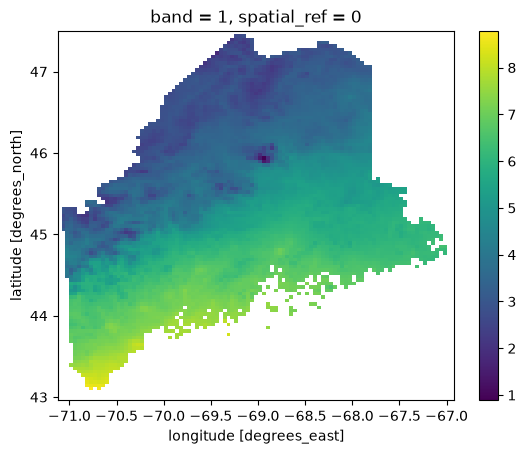

In [46]:
# Plot bio1_maine here.
bio1_maine.plot(cmap="viridis")

## 8. Choose three additional bioclimatic variables

Choose three variables from BIO2 through BIO19. Include at least one temperature variable and at least one precipitation variable.

Do not choose variables only because they are available. Give a short biological reason for each choice.

**Variable 1 and justification:** bioclim 4: temperatuer seasonality - important driver in the north

**Variable 2 and justification:** bioblim14: precip of driest month - important limiting factor for phibs?

**Variable 3 and justification:** bio6 min temp of coldest month - freezing phibs

## 9. Open the first additional raster

Build its filename, open it with `masked=True`, and inspect its CRS, shape, resolution, and bounds.

In [53]:
# Open your first additional raster.
bioclim_path = Path("C:/Users/Braec/Desktop/BIO597-SpatialBiodiversity/bioclim")
bio4_path = bioclim_path / "wc2.1_2.5m_bio_4.tif"

bio4 = rxr.open_rasterio(
    bioclim_path / "wc2.1_2.5m_bio_4.tif",
    masked=True,
)

bio4
# Inspect its metadata.

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  2377.6240234375
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  0
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

## 10. Check alignment with BIO1

Compare CRS, shape, resolution, and bounds. Each comparison should return `True` before you treat the rasters as an aligned stack.

In [54]:
# Compare the first additional raster with bio1.
print("Same CRS:", bio1.rio.crs == bio4.rio.crs)
print("Same shape:", bio1.shape == bio4.shape)
print("Same resolution:", bio1.rio.resolution() == bio4.rio.resolution())
print("Same bounds:", bio1.rio.bounds() == bio4.rio.bounds())

Same CRS: True
Same shape: True
Same resolution: True
Same bounds: True


## 11. Clip and map the first additional raster

Use the same clipping settings as BIO1. Plot the Maine result with an appropriate colormap.

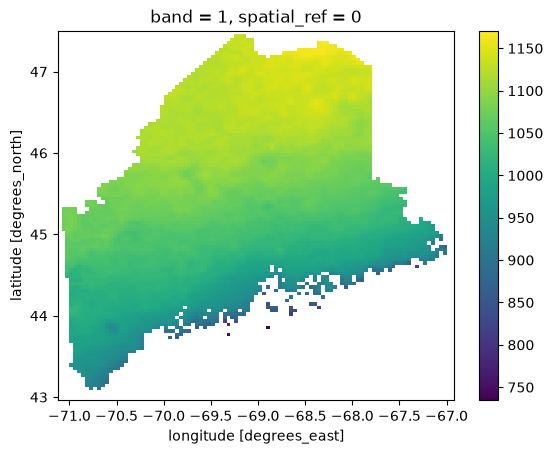

In [56]:
# Clip, squeeze, and plot the first additional raster.
bio4_maine = bio4.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio4_maine = bio4_maine.squeeze()
bio4_maine.plot(cmap="viridis")

## 12. Repeat for the second additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it. Keep each part of the workflow visible in your code.

In [57]:
# Complete the workflow for the second additional raster.
# Open your first additional raster.
bioclim_path = Path("C:/Users/Braec/Desktop/BIO597-SpatialBiodiversity/bioclim")
bio14_path = bioclim_path / "wc2.1_2.5m_bio_14.tif"

bio14 = rxr.open_rasterio(
    bioclim_path / "wc2.1_2.5m_bio_14.tif",
    masked=True,
)

bio14
# Inspect its metadata.

<xarray.DataArray (band: 1, y: 4320, x: 8640)> Size: 149MB
[37324800 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * y            (y) float64 35kB 89.98 89.94 89.9 89.85 ... -89.9 -89.94 -89.98
  * x            (x) float64 69kB -180.0 -179.9 -179.9 ... 179.9 179.9 180.0
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:       Area
    STATISTICS_MAXIMUM:  507
    STATISTICS_MEAN:     nan
    STATISTICS_MINIMUM:  0
    STATISTICS_STDDEV:   nan
    scale_factor:        1.0
    add_offset:          0.0

In [58]:
# Compare the first additional raster with bio1.
print("Same CRS:", bio1.rio.crs == bio14.rio.crs)
print("Same shape:", bio1.shape == bio14.shape)
print("Same resolution:", bio1.rio.resolution() == bio14.rio.resolution())
print("Same bounds:", bio1.rio.bounds() == bio14.rio.bounds())

Same CRS: True
Same shape: True
Same resolution: True
Same bounds: True


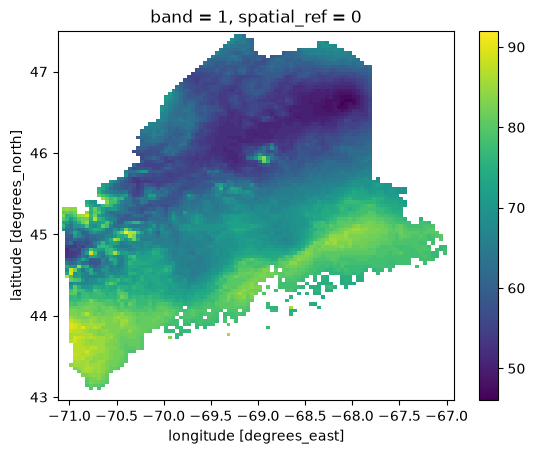

In [59]:
# Clip, squeeze, and plot the first additional raster.
bio14_maine = bio14.rio.clip(
    maine_boundary.geometry,
    maine_boundary.crs,
    drop=True,
    from_disk=True,
)

bio14_maine = bio14_maine.squeeze()
bio14_maine.plot(cmap="viridis")

## 13. Repeat for the third additional raster

Open the raster, confirm alignment, clip it to Maine, and plot it.

In [51]:
# Complete the workflow for the third additional raster.

## 14. Load the amphibian records

Read the tab-delimited occurrence file. Keep `gbifID`, `species`, longitude, latitude, and year.

In [52]:
amphibians = pd.read_csv(
    "Amphibians_ME/Amphibians_ME.csv",
    sep=__________,
    low_memory=False,
)

# Keep the five requested columns.

NameError: name '__________' is not defined

## 15. Prepare the occurrence coordinates

Convert longitude and latitude to numeric columns. Remove records missing species or coordinates.

In [ ]:
# Convert both coordinate columns with pd.to_numeric().
# Drop rows missing species, longitude, or latitude.

## 16. Choose three amphibian species

Inspect the species counts, then choose three species with enough records for comparison.

In [ ]:
amphibians["species"].value_counts().head(20)

**Species 1:**

**Species 2:**

**Species 3:**

In [ ]:
selected_species = [
    "____________________________",
    "____________________________",
    "____________________________",
]

# Filter the occurrence table with .isin(selected_species).

## 17. Create an occurrence GeoDataFrame

Use longitude and latitude to create point geometry. Assign `EPSG:4326`.

In [ ]:
# Create selected_amphibians_gdf here.

## 18. Confirm coordinate systems

Print the occurrence CRS and raster CRS. Explain what must be true before extracting raster values.

In [ ]:
# Print both coordinate systems.

**Your explanation:**

## 19. Prepare coordinates for extraction

Create `xarray.DataArray` objects called `point_x` and `point_y`. Use one dimension named `record`.

In [ ]:
# Create point_x from point longitude.
# Create point_y from point latitude.

## 20. Extract annual mean temperature

Use `.sel()` with `x`, `y`, and `method="nearest"`. Add the extracted values to a clearly named column in the occurrence GeoDataFrame.

In [ ]:
bio1_values = bio1_maine.sel(
    x=__________,
    y=__________,
    method=__________,
)

# Add the values to selected_amphibians_gdf.

## 21. Inspect missing extracted values

Count missing BIO1 values. Explain why coastal occurrences may be assigned NoData even when the coordinates are valid.

In [ ]:
# Count missing extracted BIO1 values.

**Your explanation:**

## 22. Extract the three additional variables

Use the same `point_x` and `point_y` arrays. Add one clearly named column for each variable. The column names should include units where practical.

In [ ]:
# Extract values from the first additional clipped raster.
# Add the values to selected_amphibians_gdf.

In [ ]:
# Extract values from the second additional clipped raster.
# Add the values to selected_amphibians_gdf.

In [ ]:
# Extract values from the third additional clipped raster.
# Add the values to selected_amphibians_gdf.

## 23. Create the occurrence-environment table

Remove the geometry column and display the first five rows. Confirm that the table contains species, coordinates, year, and four environmental variables.

In [ ]:
# Create and display occurrence_environment.

## 24. Summarize environmental values by species

For each selected species, calculate:

* number of records
* mean of each environmental variable
* standard deviation of each environmental variable

In [ ]:
# Calculate species-level summaries here.

## 25. Check relationships among predictors

Create a correlation table for your four environmental variables. Identify any pair with a strong relationship.

In [ ]:
# Select the four predictor columns and calculate .corr().

**Interpretation:** Which predictors contain similar information? Would you retain all of them in the same model? Explain your reasoning.

## 27. Save your occurrence-environment table

Save it as `Assignment05_environmental_values.csv` beside this notebook. Do not include the DataFrame index.

In [ ]:
# Save occurrence_environment with .to_csv().

## Final reflection

Answer each question in two or three sentences.

1. How do raster resolution and occurrence-coordinate uncertainty interact?
2. What environmental variation is lost when all occurrences in one raster cell receive the same value?
3. Which predictor has the strongest biological justification for your selected species?
4. Which preprocessing choice is most important to document for reproducibility?
5. Name one additional environmental predictor you would seek for an amphibian study and explain why.

## Submit your work

Run the notebook from top to bottom. Make sure all raster maps, tables, and written answers are complete. Then commit and push the completed notebook to your class GitHub repository.

```bash
git add docs/assignments/Assignment-05-RasterData.ipynb
git commit -m "Complete raster data assignment"
git push
```